In [3]:
# Kütüphaneler import edilerek dahil edilir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
# random.seed(42) # random seed kullanabiliriz
#{:.2f} virgülden sonra kaç hane istiyorsak değeri bu şekilde girebiliriz.

# Örnek (Sentetik) Veri Setinin Oluşturulması 

In [7]:
np.random.seed(42)

# Müşteri sayısı
n = 1000

df_musteri = pd.DataFrame({
    "yas": np.random.randint(18, 71, n),    
    "gelir": np.random.randint(15000, 100000, n),    
    "sehir": np.random.choice(["İstanbul", "Ankara", "İzmir", "Bursa", "Antalya"],n),    
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"],n),    
    "kayit_tarihi": pd.to_datetime(np.random.choice(pd.date_range("2022-01-01", "2025-12-31"),n)),
    "aylik_harcama": np.round(np.random.uniform(100, 5000, n),2),    
    "memnuniyet_puani": np.random.randint(1, 11, n),    
    "churn": np.random.choice([0, 1],n,p=[0.8, 0.2])
})

print(df_musteri.head())
print(df_musteri.shape)

   yas  gelir    sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0   56  15302    Bursa      Standart   2023-12-19         200.55   
1   69  97558    Bursa         Temel   2024-11-06        4150.43   
2   46  15055  Antalya       Premium   2022-10-01        1891.42   
3   32  23717    İzmir      Standart   2023-11-16        1833.11   
4   60  43699   Ankara       Premium   2022-04-26        1582.15   

   memnuniyet_puani  churn  
0                 6      1  
1                 5      0  
2                10      0  
3                 6      1  
4                 9      0  
(1000, 8)


In [10]:
# Eksik değerler
df_musteri.loc[
    np.random.choice(df_musteri.index, 15, replace=False),
    "gelir"
] = np.nan

df_musteri.loc[
    np.random.choice(df_musteri.index, 10, replace=False),
    "yas"
] = np.nan

df_musteri.loc[
    np.random.choice(df_musteri.index, 15, replace=False),
    "memnuniyet_puani"
] = np.nan
print(df_musteri.isnull().sum())

yas                 29
gelir               44
sehir                0
abonelik_tipi        0
kayit_tarihi         0
aylik_harcama        0
memnuniyet_puani    45
churn                0
dtype: int64


In [12]:
print(df_musteri.shape)
df_musteri.info()

(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   yas               971 non-null    float64       
 1   gelir             956 non-null    float64       
 2   sehir             1000 non-null   object        
 3   abonelik_tipi     1000 non-null   object        
 4   kayit_tarihi      1000 non-null   datetime64[ns]
 5   aylik_harcama     1000 non-null   float64       
 6   memnuniyet_puani  955 non-null    float64       
 7   churn             1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 62.6+ KB


In [14]:
print(df_musteri.head(5))
print(df_musteri.head(3))
print(df_musteri.sample(5, random_state=42))

    yas    gelir    sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0  56.0  15302.0    Bursa      Standart   2023-12-19         200.55   
1  69.0  97558.0    Bursa         Temel   2024-11-06        4150.43   
2  46.0  15055.0  Antalya       Premium   2022-10-01        1891.42   
3  32.0      NaN    İzmir      Standart   2023-11-16        1833.11   
4  60.0  43699.0   Ankara       Premium   2022-04-26        1582.15   

   memnuniyet_puani  churn  
0               6.0      1  
1               NaN      0  
2               NaN      0  
3               6.0      1  
4               9.0      0  
    yas    gelir    sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0  56.0  15302.0    Bursa      Standart   2023-12-19         200.55   
1  69.0  97558.0    Bursa         Temel   2024-11-06        4150.43   
2  46.0  15055.0  Antalya       Premium   2022-10-01        1891.42   

   memnuniyet_puani  churn  
0               6.0      1  
1               NaN      0  
2               NaN      0 

In [15]:
print(df_musteri.duplicated().sum())

0


Korelasyon Matrisi:
                       yas     gelir  aylik_harcama  memnuniyet_puani  \
yas               1.000000  0.008816       0.042089          0.004931   
gelir             0.008816  1.000000       0.032605          0.008351   
aylik_harcama     0.042089  0.032605       1.000000          0.044306   
memnuniyet_puani  0.004931  0.008351       0.044306          1.000000   
churn             0.029508  0.052232      -0.035704          0.019717   

                     churn  
yas               0.029508  
gelir             0.052232  
aylik_harcama    -0.035704  
memnuniyet_puani  0.019717  
churn             1.000000  


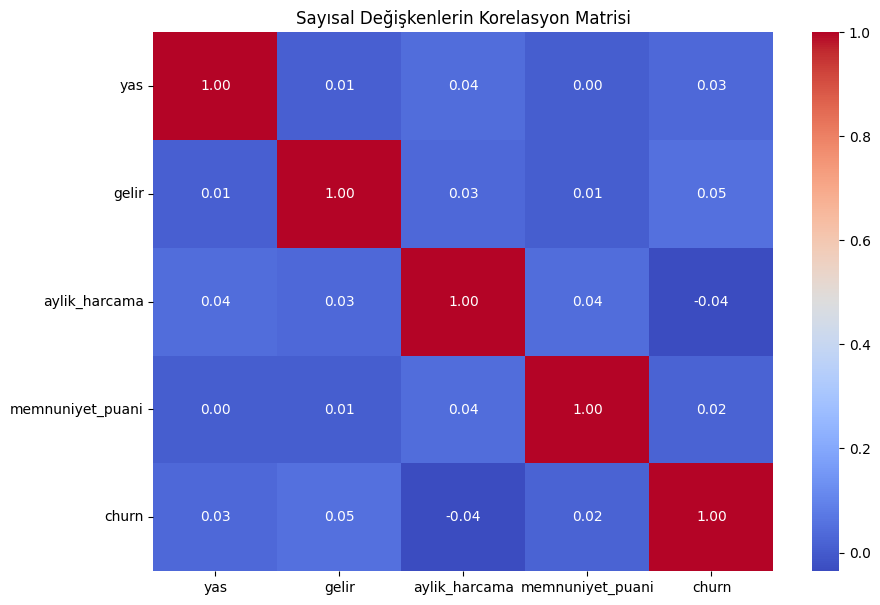

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Korelasyon matrisi
korelasyon = df_musteri.corr(numeric_only=True)

print("Korelasyon Matrisi:")
print(korelasyon)

# Isı haritası
plt.figure(figsize=(10, 7))

sns.heatmap(
    korelasyon,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Sayısal Değişkenlerin Korelasyon Matrisi")
plt.show()